## Máster en Big Data y Data Science

### Metodologías de gestión y diseño de proyectos de big data

#### AP2 - Modelado y evaluación

---

En esta libreta se realiza la experimentación para generación del modelo de predicción objetivo del proyecto y la evaluación del mismo.
La versión del dataset a utilizar es la obtenida a partir de las operaciones de transformación.

In [20]:
# Se importan las librerías necesarias y se suprimen las advertencias
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore',category=FutureWarning)
warnings.filterwarnings('ignore',category=UserWarning)

In [5]:
# Lectura de los datos
df = pd.read_csv('../data/processed/datos_integrados.csv')
df.head(5)

,edad,antiguedad_empleado,situacion_vivienda,ingresos,objetivo_credito,pct_ingreso,tasa_interes,estado_credito,falta_pago,antiguedad_cliente,...,genero,limite_credito_tc,nivel_educativo,personas_a_cargo,capacidad_pago,operaciones_mensuales,presion_financiera,gasto_promedio_operacion,operaciones_mensuales_tc,estabilidad_laboral
0,22,123.0,ALQUILER,59000,PERSONAL,0.59,16.02,1,Y,36.0,...,M,4010.0,UNIVERSITARIO_COMPLETO,2.0,0.593220,2.000000,0.216181,45.333333,2.000000,5.590909
1,21,5.0,PROPIA,9600,EDUCACIÓN,0.10,11.14,0,N,39.0,...,M,12691.0,SECUNDARIO_COMPLETO,3.0,0.104167,3.500000,0.171250,27.238095,3.500000,0.238095
2,25,1.0,HIPOTECA,9600,SALUD,0.57,12.87,1,N,44.0,...,F,8256.0,UNIVERSITARIO_COMPLETO,5.0,0.572917,2.750000,0.325451,39.121212,2.750000,0.040000
3,23,4.0,ALQUILER,65500,SALUD,0.53,15.23,1,N,36.0,...,M,3418.0,UNIVERSITARIO_COMPLETO,3.0,0.534351,1.666667,0.295985,94.350000,1.666667,0.173913
4,24,8.0,ALQUILER,54400,SALUD,0.55,14.27,1,Y,54.0,...,M,9095.0,DESCONOCIDO,1.0,0.643382,2.166667,0.185000,50.538462,2.166667,0.333333


In [21]:
def reporte_descripcion_dataset(df):
    columnas = df.columns
    print("Columnas del dataset:\n")
    for col in columnas:
        print(col)
    print(f"\nCantidad de filas: {df.shape[0]}")

print("Descripción del dataset 'datos_integrados.csv':\n")
reporte_descripcion_dataset(df)

Descripción del dataset 'datos_integrados.csv':

Columnas del dataset:

edad
antiguedad_empleado
situacion_vivienda
ingresos
objetivo_credito
pct_ingreso
tasa_interes
estado_credito
falta_pago
antiguedad_cliente
estado_civil
estado_cliente
gastos_ult_12m
genero
limite_credito_tc
nivel_educativo
personas_a_cargo
capacidad_pago
operaciones_mensuales
presion_financiera
gasto_promedio_operacion
operaciones_mensuales_tc
estabilidad_laboral

Cantidad de filas: 10123


In [23]:
# Se divide el dataset en variables predictoras y variable objetivo
target = "falta_pago"

features_X = df.drop(columns=[target])
labels_y = df[target]

print("Dimensiones X:", features_X.shape)
print("Dimensiones y:", labels_y.shape)

Dimensiones X: (10123, 22)
Dimensiones y: (10123,)


In [24]:
# Se genera el conjunto de entrenamiento, validación y test con estratificación

# Primero separar test final (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    features_X,
    labels_y,
    test_size=0.10,
    random_state=42,
    stratify=labels_y
)

# Luego separar train y validation (22% del 90% es aprox. el 20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.22,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (7105, 22)
Validation: (2005, 22)
Test: (1013, 22)


In [25]:
# Se identifican las columnas numéricas y categóricas

num_cols = features_X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = features_X.select_dtypes(include=["object","category"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['edad', 'antiguedad_empleado', 'ingresos', 'pct_ingreso', 'tasa_interes', 'estado_credito', 'antiguedad_cliente', 'gastos_ult_12m', 'limite_credito_tc', 'personas_a_cargo', 'capacidad_pago', 'operaciones_mensuales', 'presion_financiera', 'gasto_promedio_operacion', 'operaciones_mensuales_tc', 'estabilidad_laboral']
Categóricas: ['situacion_vivienda', 'objetivo_credito', 'estado_civil', 'estado_cliente', 'genero', 'nivel_educativo']


C:\Users\roger\AppData\Local\Temp\ipykernel_24644\3205626189.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = features_X.select_dtypes(include=["object","category"]).columns.tolist()


In [26]:
# Se verifica la distribución de la variable objetivo en el conjunto de entrenamiento
y_train.value_counts()

falta_pago
N    5864
Y    1241
Name: count, dtype: int64

In [27]:
# Se crea un pipeline para preprocesamiento de datos

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [28]:
# Se crea un pipeline completo con preprocesamiento y modelo base

baseline = Pipeline([
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_val)

print("Baseline accuracy:", accuracy_score(y_val, y_pred))

Baseline accuracy: 0.8254364089775561


In [29]:
# Se definen los modelos a evaluar

modelos = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "LinearSVC": LinearSVC(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=42
    )
}

In [30]:
# Se evaluan los modelos con validación cruzada comparando sus resultados

resultados = []

for nombre, modelo in modelos.items():
    # Se aplica el preprocesamiento
    pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", modelo)
    ])

    # Se evalúan los modelos con validación cruzada
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    # Se almacenan los resultados
    resultados.append({
        "modelo": nombre,
        "accuracy_media": scores.mean(),
        "std": scores.std()
    })

df_resultados = pd.DataFrame(resultados)

df_resultados.sort_values("accuracy_media", ascending=False)

,modelo,accuracy_media,std
4,RandomForest,0.907108,0.002707
1,LinearSVC,0.893174,0.005476
0,LogisticRegression,0.891063,0.003430
2,KNN,0.878255,0.005769
3,DecisionTree,0.868403,0.006511


In [31]:
# Se entrena el mejor modelo

modelo_final = Pipeline([
    ("prep", preprocessor),
    ("model", LinearSVC(max_iter=5000))
])

modelo_final.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [32]:
# Se evalúan los resultados en el conjunto de validación

y_val_pred = modelo_final.predict(X_val)

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           N       0.92      0.95      0.93      1655
           Y       0.71      0.59      0.65       350

    accuracy                           0.89      2005
   macro avg       0.82      0.77      0.79      2005
weighted avg       0.88      0.89      0.88      2005



In [34]:
# Se evalúan los resultados en el conjunto de test

y_test_pred = modelo_final.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           N       0.92      0.95      0.93       836
           Y       0.71      0.62      0.66       177

    accuracy                           0.89      1013
   macro avg       0.82      0.78      0.80      1013
weighted avg       0.89      0.89      0.89      1013



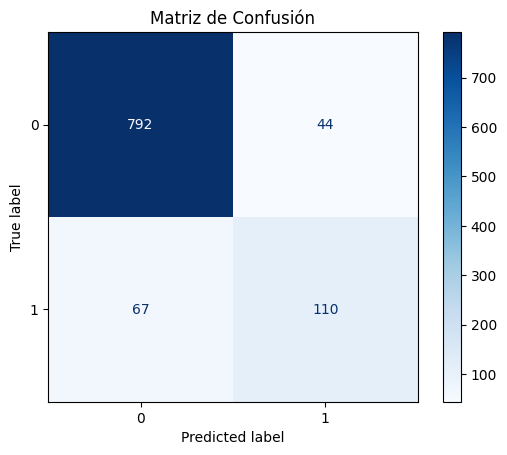

In [35]:
# Se genera una matriz de confusión para el conjunto de test

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusión")
plt.show()